In [ ]:
import numpy as np
import xarray as xr
import scipy as sci
import matplotlib.pyplot as plt # still need matplotlib
import xmitgcm
import xgcm 
import gsw

import cartopy.crs as ccrs
import matplotlib.ticker as mticker

In [2]:
# Importing my budget codes
import O2age_budget  
from O2age_budget import AgeBudgetND as AgeBud 

In [3]:

# First just want to load the data. 

myYr = np.arange(1,100) # here loading everything. 
print(myYr)
#myIts = 1080000 + 720*myYr
myIts = 2880000 + 720*myYr
#print(myIts)
SnIts = np.concatenate(([myIts[0]-720], myIts)) # snapshot times. 

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
 97 98 99]


In [4]:
fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
folPac = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/saved_data/Pacfade_4C/'
folSO = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/saved_data/SOfade_4C/'
fol0 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/Control_try1/'

#folSOfade = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/saved_data/SOfade_4C/'

Pac3d = xmitgcm.open_mdsdataset(folPac, grid_dir = fol3, prefix = [ 'DynDiag3d','AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
vol = Pac3d.drF*Pac3d.hFacC*Pac3d.rA
SO3d = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
Ctl3d = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
SO3d = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)

PacSn = xmitgcm.open_mdsdataset(folPac, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)
SOSn = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)
CtlSn = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)

# Interesting that I don't process to make the 0's into nan's. Hopefully this doesn't become an issue at any point. Maybe I should process what I end up plotting... 


/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/n

In [7]:
## We only look at the final decade for Pacific 

PacAge = AgeBud(Pac3d, PacSn)
PacAge.calc_all()
SOAge = O2age_budget.AgeBudgetND(SO3d, SOSn)
SOAge.calc_all()
CtlAge = AgeBud(Ctl3d, CtlSn)
CtlAge.calc_all()

PacO2 = O2age_budget.OxygenBudget(Pac3d, PacSn)
PacO2.calc_all()
SOO2 = O2age_budget.OxygenBudget(SO3d, SOSn)
SOO2.calc_all()
CtlO2 = O2age_budget.OxygenBudget(Ctl3d, CtlSn)
CtlO2.calc_all()

/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a

In [8]:
## taking the means of the budget terms for Pacific section!
# Note that we only use the last decade! 
# there's a better way to do this it turns out .. 

xran = range(64,80) # 65,85 is what i used for a while; 54,74 is what I used in Fig 2.
yran = range(20,53)
zran = range(17)
tran = range(89,99)

# Oxygen averages
# really weird naming convention, but it works... A is Pacific
PoAw = PacO2.terms.advr_nd_O2.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
Po0w = CtlO2.terms.advr_nd_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')

PoAadv = PacO2.terms.advct_O2.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
Po0adv = CtlO2.terms.advct_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')

PoAdiff =  PacO2.terms.diffu_O2.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
Po0diff = CtlO2.terms.diffu_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')

PoAtend = PacO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
Po0tend = CtlO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')

PoAbio = PacO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
Po0bio = CtlO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')

PlAw = PacAge.terms.advr_nd_Age.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
Pl0w = CtlAge.terms.advr_nd_Age.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')

PlAadv = PacAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
Pl0adv = CtlAge.terms.advct_Age.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')

PlAtot = PacAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time') + PacAge.terms.diffu_Age.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
Pl0tot = CtlAge.terms.advct_Age.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time') + CtlAge.terms.diffu_Age.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')



#PlAwg = Pacwgrad.isel( XC = xran, YC = yran, Z= zran).mean('XC').mean('time')
#PlBwg = SOwgrad.isel( XC = xran, YC = yran, Z= zran).mean('XC').mean('time')

In [9]:
## OK I'm bringing in some info about the total change.
# I think this is redundant a bit, but should be fine. 

myYrten = np.arange(90,100)
#print(myYr)
myItstend = 2880000 + 720*myYrten
#folPac = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4CPac_try1/'
PacTend = xmitgcm.open_mdsdataset(folPac, grid_dir = fol3, prefix = ['DICDiag3d'], iters = myItstend.tolist(), ignore_unknown_vars = True)
#fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
#fol0 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/Control_try1/'
CtlTend = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DICDiag3d'], iters = myItstend.tolist(), ignore_unknown_vars = True)


o2Pact = xr.where(PacTend.TRAC05 ==0, np.nan, PacTend.TRAC05).mean('time')
agePact= xr.where(PacTend.TRAC11 ==0, np.nan, PacTend.TRAC11).mean('time')
o2cont= xr.where(CtlTend.TRAC05 ==0, np.nan, CtlTend.TRAC05).mean('time')
agecont= xr.where(CtlTend.TRAC11 ==0, np.nan, CtlTend.TRAC11).mean('time')

xran = range(64,80) # 65,85 is what i used for a while; 54,74 is what I used in Fig 2.
yran = range(20,53)
zran = range(17)

o2Pac90 = o2Pact.isel(XC = xran, YC = yran, Z= zran).mean('XC') - o2cont.isel(XC = xran, YC = yran, Z= zran).mean('XC')
agePac90 = agePact.isel(XC = xran, YC = yran, Z= zran).mean('XC') - agecont.isel(XC = xran, YC = yran, Z= zran).mean('XC')

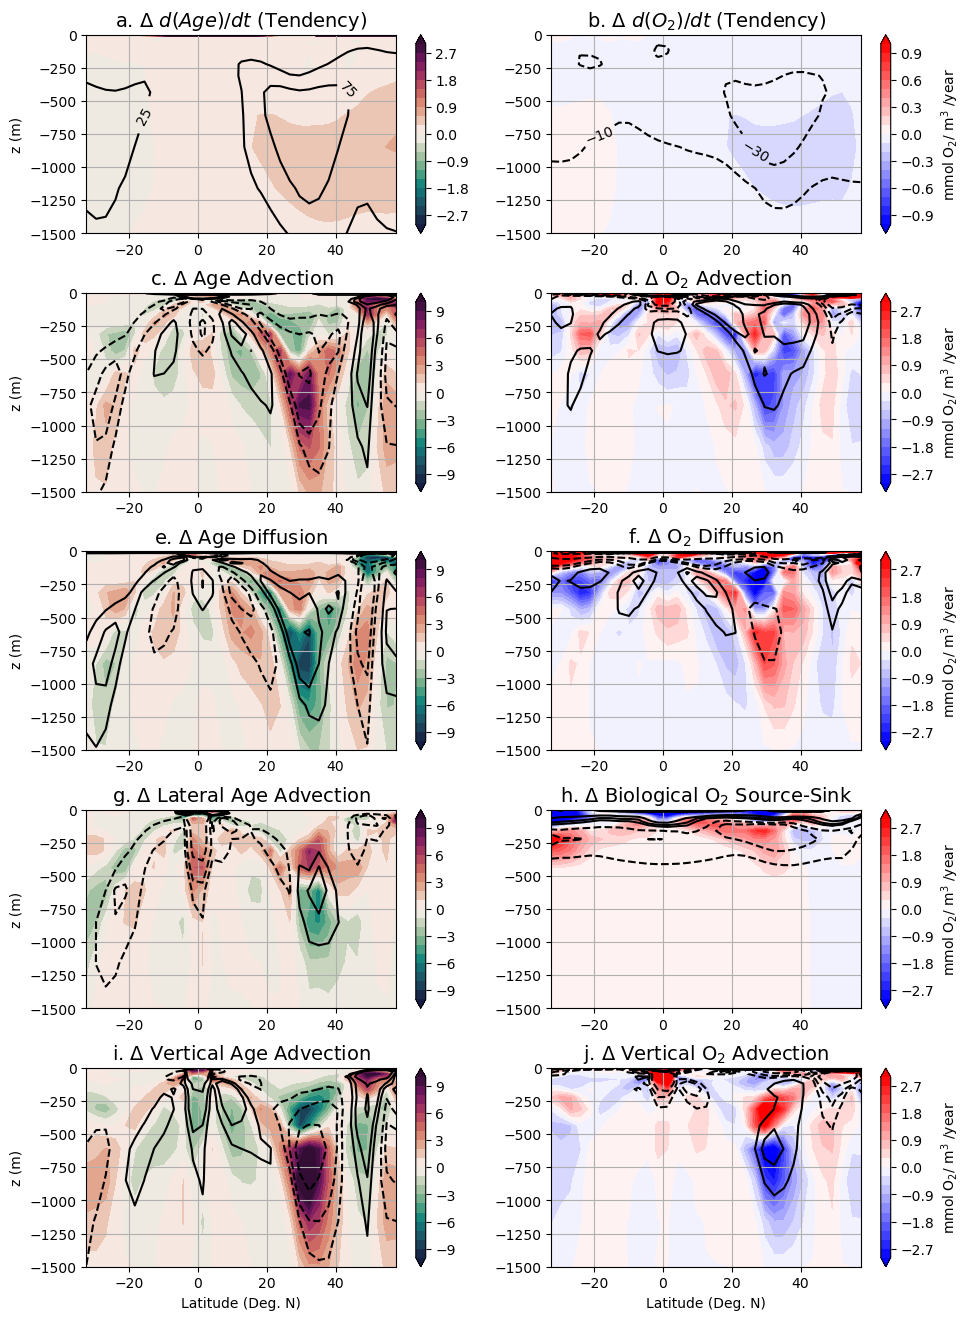

In [12]:
## Pacific zonal mean budget with both AGE and OXYGEN
# oxygen will be more interesting to the BGC people 

# WOW this is about to be the most EPIC budget figure ever! 

PlAhor = PlAadv - PlAw 
Pl0hor = Pl0adv - Pl0w 

import cmocean
agemap = cmocean.cm.curl
o2map = 'bwr'

zdep = 1500
vm = 10
vmo = 3
vmot = 1
vmat = 3

fig, axs = plt.subplots(ncols=2 , nrows=5, figsize=(11,16))
plt.rcParams['text.usetex'] = False

ageclev = [-20,-10, -5, 5, 10, 20]
o2clev = [-12,-6, -3, 3, 6, 12]
lw = 1.5

tfon = 14
Diag3d = Pac3d

E = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAtot - Pl0tot)  , vmin = -vmat, vmax = vmat, levels = np.linspace(-vmat, vmat,21), cmap = agemap, extend = 'both')
aget1 = axs[0,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], agePac90, levels = [25, 75],colors= 'k')
aget1.clabel()#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(E, ax= axs[0,0])
axs[0,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0,0].grid()

F = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PoAtend - Po0tend), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = o2map, extend = 'both')
o2t1 = axs[0,1].contour(Diag3d.YC[yran], Diag3d.Z[zran],1000*o2Pac90, levels = [-30, -10, 10], colors= 'k')
o2t1.clabel()
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Fcb = plt.colorbar(F, ax= axs[0,1])
Fcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[0,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0,1].grid()


axs[0,1].set_title('b. $\Delta$ $d(O_2)/dt$ (Tendency)', fontsize = tfon)
axs[0,0].set_title('a. $\Delta$ $d(Age)/dt$ (Tendency)', fontsize = tfon)



C = axs[1,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAadv - Pl0adv), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[1,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*( Pl0adv)  , levels = ageclev, colors='k', linewidths = lw)
plt.colorbar(C, ax= axs[1,0])
axs[1,0].set_ylim([-zdep,0])
axs[1,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAtot - Pl0tot),levels = [1.2, 2.4], colors='black', linewidths=1)
axs[1,0].grid()

D = axs[1,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PoAadv- Po0adv), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[1,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*( Po0adv), levels = o2clev, colors= 'k')

Dcb = plt.colorbar(D, ax= axs[1,1])
Dcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[1,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1,1].grid()


axs[1,1].set_title('d. $\Delta$ O$_2$ Advection', fontsize = tfon)# $-div $[O_2*u]$ (O$_2$ Advection)')
axs[1,0].set_title('c. $\Delta$ Age Advection', fontsize = tfon) #-div $[Age*u]$ (Age Advection)')


C = axs[2,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAtot - PlAadv - Pl0tot + Pl0adv)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[2,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*( Pl0tot- Pl0adv)  , levels = ageclev, colors='k', linewidths = lw)
plt.colorbar(C, ax= axs[2,0])
axs[2,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[2,0].grid()

M = axs[2,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PoAdiff - Po0diff), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[2,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*( Po0diff), levels = o2clev, colors= 'k')
Mcb = plt.colorbar(D, ax= axs[2,1])
Mcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[2,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[2,1].grid()


axs[2,1].set_title('f. $\Delta$ O$_2$ Diffusion', fontsize = tfon)
axs[2,0].set_title('e. $\Delta$ Age Diffusion', fontsize = tfon)



A = axs[3,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAhor - Pl0hor)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[3,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*( Pl0hor)  , levels = ageclev, colors='k', linewidths = lw)
plt.colorbar(A, ax= axs[3,0])
axs[3,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[3,0].grid()

B = axs[3,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PoAbio- Po0bio), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[3,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*( Po0bio), levels = o2clev, colors= 'k')
Bcb = plt.colorbar(B, ax= axs[3,1])
Bcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[3,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[3,1].grid()


#axs[3,1].set_title('$\Delta$  $[w *d(O_2)/dz]$')
axs[3,1].set_title('h. $\Delta$ Biological O$_2$ Source-Sink', fontsize = tfon)
axs[3,0].set_title('g. $\Delta$ Lateral Age Advection', fontsize = tfon) #'$\Delta$  $[u *d(Age)/dx + v*d(Age)/dy]$ (Horiz. Adv.)')

I = axs[4,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAw - Pl0w)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
axs[4,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*( Pl0w)  , levels = ageclev, colors='k', linewidths = lw)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(I, ax= axs[4,0])
axs[4,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[4,0].grid()

J = axs[4,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PoAw- Po0w), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[4,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*( Po0w), levels = o2clev, colors= 'k')
Jcb = plt.colorbar(J, ax= axs[4,1])
Jcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[4,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[4,1].grid()


#axs[3,1].set_title('$\Delta$  $[w *d(O_2)/dz]$')
axs[4,1].set_title('j. $\Delta$ Vertical O$_2$ Advection', fontsize = tfon)#'$\Delta$   $[w *d(O_2)/dz]$(Vertical Oxygen Advection)')
axs[4,0].set_title('i. $\Delta$ Vertical Age Advection', fontsize = tfon)

#letters = ['a','b','c','d','e','f','g','h','i','j']
#for i in range(5):
#    for j in range(2):
#        axs[i,j].text(0.07, 0.1, letters[2*i+j], fontsize=14, transform=axs[i,j].transAxes, ha='left', va='top')

# this is pretty neat! 

#for i in range(1,5):
#    axs[i,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAtot - Pl0tot),levels = [1.2, 2.4], colors='black', linewidths=1)
#    axs[i,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PoAtend - Po0tend), levels = [-0.8, -0.4], colors = 'black', linewidths = 1)


        
#E = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAtot - Pl0tot)  , vmin = -vmat, vmax = vmat, levels = np.linspace(-vmat, vmat,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)

#plt.colorbar(E, ax= axs[0,0])
#axs[0,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
#axs[0,0].grid()

#F = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PoAtend - Po0tend), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = o2map, extend = 'both')

#consider cutting this off at 1500 m instead? 
#axs[2,0].set_xlabel('Deg. N') 
axs[4,1].set_xlabel('Latitude (Deg. N)') 
axs[4,0].set_xlabel('Latitude (Deg. N)') 

axs[0,0].set_ylabel('z (m)')
axs[1,0].set_ylabel('z (m)')
axs[2,0].set_ylabel('z (m)')
axs[3,0].set_ylabel('z (m)')
axs[4,0].set_ylabel('z (m)')
plt.subplots_adjust(hspace=0.3)

plt.savefig('../eps_figures/budget_sections_meancontours_4-30.eps', bbox_inches="tight")

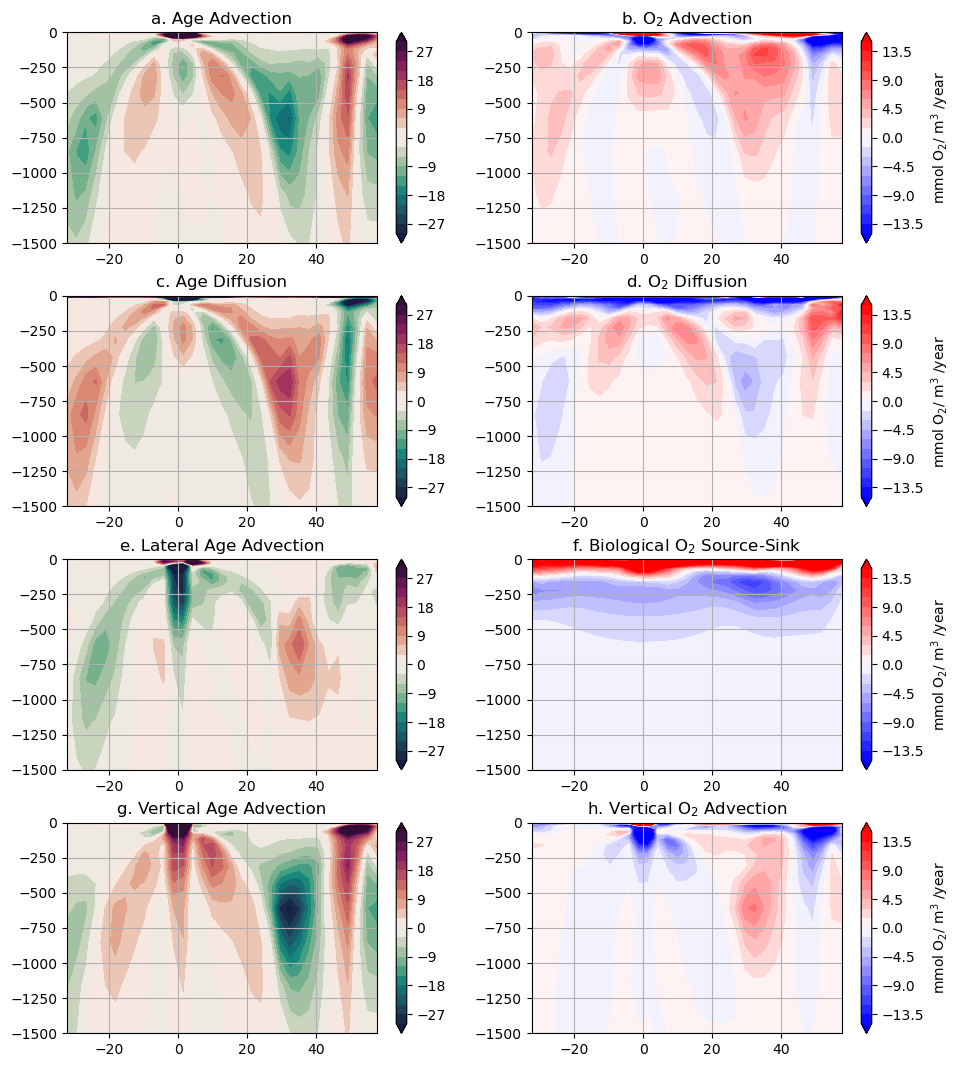

In [15]:
## OK here I want to try just redoing the previous plot but only for the control state (supplemental!) 

PlAhor = PlAadv - PlAw 
Pl0hor = Pl0adv - Pl0w 

import cmocean
agemap = cmocean.cm.curl
o2map = 'bwr'

zdep = 1500
vm = 30
vmo = 15
vmot = 1
vmat = 3
# this is truly not working. OK not a priority!! 

fig, axs = plt.subplots(ncols=2 , nrows=4, figsize=(11,13))
plt.rcParams['text.usetex'] = False

Diag3d = Pac3d

#E = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(Pl0tot)  , vmin = -vmat, vmax = vmat, levels = np.linspace(-vmat, vmat,21), cmap = agemap, extend = 'both')
##plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
##plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(E, ax= axs[0,0])
#axs[0,0].set_ylim([-zdep,0])
##axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
#axs[0,0].grid()
#
#F = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(Po0tend), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = o2map, extend = 'both')
##plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
##plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#Fcb = plt.colorbar(F, ax= axs[0,1])
#Fcb.set_label('mmol O$_2$/ m$^3$ /year')
#axs[0,1].set_ylim([-zdep,0])
##axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
#axs[0,1].grid()
#
#
#axs[0,1].set_title('$d(O_2)/dt$ (Tendency)')
#axs[0,0].set_title('$d(Age)/dt$ (Tendency)')



C = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*( Pl0adv), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[0,0])
axs[0,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0,0].grid()

D = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*( Po0adv), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Dcb = plt.colorbar(D, ax= axs[0,1])
Dcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[0,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0,1].grid()


axs[0,1].set_title('b. O$_2$ Advection')# $-div $[O_2*u]$ (O$_2$ Advection)')
axs[0,0].set_title('a. Age Advection') #-div $[Age*u]$ (Age Advection)')


C = axs[1,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(Pl0tot - Pl0adv)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[1,0])
axs[1,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1,0].grid()

M = axs[1,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*( Po0diff), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Mcb = plt.colorbar(D, ax= axs[1,1])
Mcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[1,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1,1].grid()


axs[1,1].set_title('d. O$_2$ Diffusion')
axs[1,0].set_title('c. Age Diffusion')



A = axs[2,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*( Pl0hor)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[2,0])
axs[2,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[2,0].grid()

B = axs[2,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(Po0bio), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Bcb = plt.colorbar(B, ax= axs[2,1])
Bcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[2,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[2,1].grid()


#axs[3,1].set_title('$\Delta$  $[w *d(O_2)/dz]$')
axs[2,1].set_title('f. Biological O$_2$ Source-Sink')
axs[2,0].set_title('e. Lateral Age Advection') #'$\Delta$  $[u *d(Age)/dx + v*d(Age)/dy]$ (Horiz. Adv.)')

I = axs[3,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*( Pl0w)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(I, ax= axs[3,0])
axs[3,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[3,0].grid()

J = axs[3,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*( Po0w), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Jcb = plt.colorbar(J, ax= axs[3,1])
Jcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[3,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[3,1].grid()


#axs[3,1].set_title('$\Delta$  $[w *d(O_2)/dz]$')
axs[3,1].set_title('h. Vertical O$_2$ Advection')#'$\Delta$   $[w *d(O_2)/dz]$(Vertical Oxygen Advection)')
axs[3,0].set_title('g. Vertical Age Advection')

#letters = ['a','b','c','d','e','f','g','h','i','j']
#for i in range(4):
#    for j in range(2):
#        axs[i,j].text(0.07, 0.1, letters[2*i+j], fontsize=14, transform=axs[i,j].transAxes, ha='left', va='top')



plt.subplots_adjust(hspace=0.25)
plt.savefig('../eps_figures/mean_budget_section_4-30.eps')


## Southern-4C budget in map form

In [16]:
# I can do the depth-average much more easily this way! Wow! 

xran = range(42,105)
yran = range(12,53)
zran = range(8,13)
deps = Pac3d.drF.isel(Z=zran)*Pac3d.hFacC.isel(XC = xran, YC = yran, Z= zran)

tmpSOO2 = SOO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
SOO2map = tmpSOO2.sum('Z')/deps.sum('Z')
tmpSOAge = SOAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
SOAgemap = tmpSOAge.sum('Z')/deps.sum('Z')

tmpCtlO2 = CtlO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
CtlO2map = tmpCtlO2.sum('Z')/deps.sum('Z')
tmpCtlAge = CtlAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
CtlAgemap = tmpCtlAge.sum('Z')/deps.sum('Z')

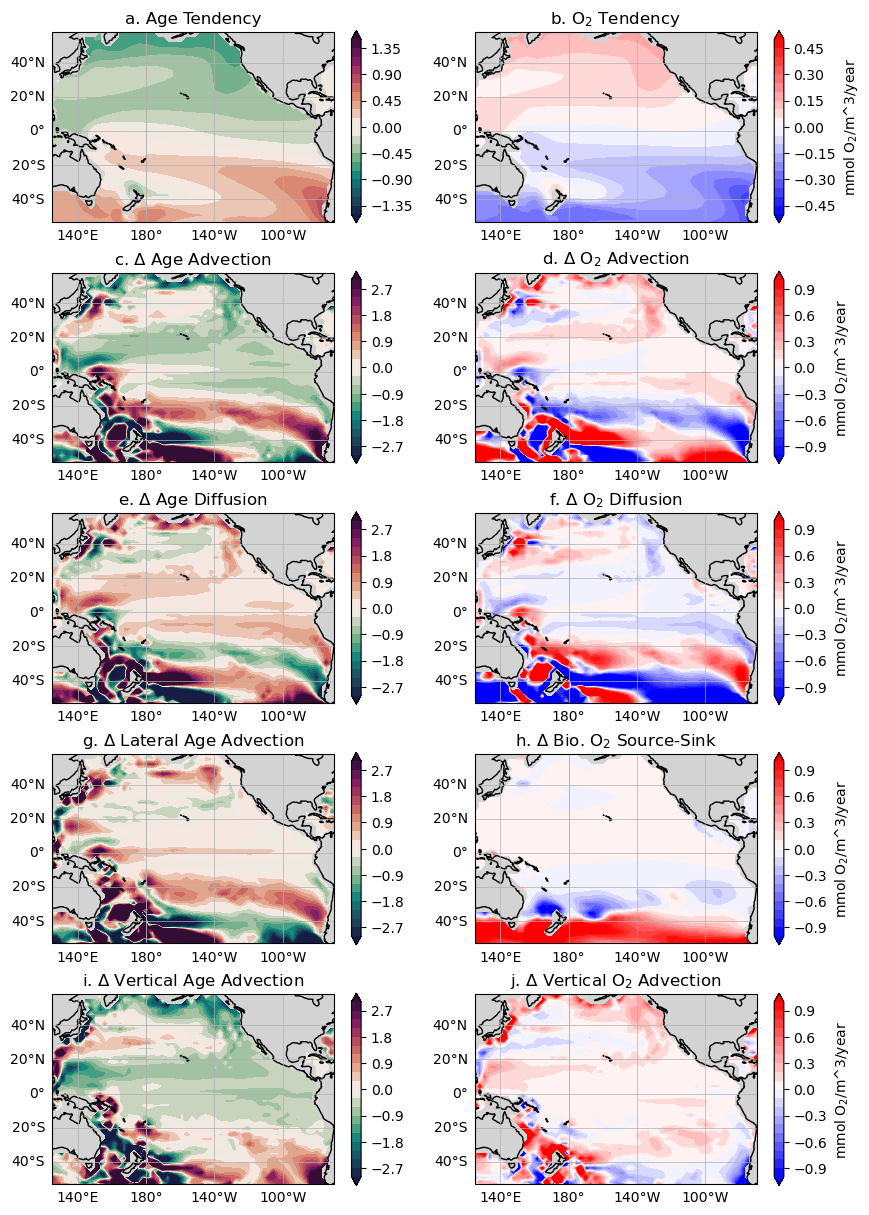

In [19]:
# Figure 10 plotting

import cmocean
agemap = cmocean.cm.curl
omap = 'bwr'

Diag3d = Pac3d

vm= 3
vmo = 1
vmt = 1.5
vmot = 0.5

ForcO = SOO2map
ForcA = SOAgemap
CtlO = CtlO2map
CtlA = CtlAgemap
tfon  =12
proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(ncols=2 , nrows=5, figsize=(10,15), subplot_kw={'projection': proj})
plt.rcParams['text.usetex'] = False

E = axs[0,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.Tend_Age -CtlA.Tend_Age)  , vmin = -vmt, vmax = vmt, levels = np.linspace(-vmt, vmt,21), cmap = agemap, extend = 'both', transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(E, ax= axs[0,0])
#axs[0,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[0,0].grid()

F = axs[0,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*360*(ForcO.Tend_O2- CtlO.Tend_O2), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Fcb=plt.colorbar(F, ax= axs[0,1])
Fcb.set_label('mmol O$_2$/m^3/year')
#axs[0,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[0,1].grid()


axs[0,0].set_title('a. Age Tendency', fontsize = tfon)
axs[0,1].set_title('b. O$_2$ Tendency', fontsize = tfon)



C = axs[1,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*( ForcA.advct_Age- CtlA.advct_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ccb = plt.colorbar(C, ax= axs[1,0])

#axs[1,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[1,0].grid()

D = axs[1,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*360*(ForcO.advct_O2- CtlO.advct_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Dcb = plt.colorbar(D, ax= axs[1,1])
Dcb.set_label('mmol O$_2$/m^3/year')

#axs[1,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[1,1].grid()


axs[1,0].set_title('c. $\Delta$ Age Advection', fontsize = tfon)
axs[1,1].set_title('d. $\Delta$ O$_2$ Advection', fontsize = tfon)


C = axs[2,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.diffu_Age - CtlA.diffu_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[2,0])
#axs[2,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[2,0].grid()

D = axs[2,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.diffu_O2 - CtlO.diffu_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ecb = plt.colorbar(D, ax= axs[2,1])
Ecb.set_label('mmol O$_2$/m^3/year')
#axs[2,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[2,1].grid()


axs[2,0].set_title('e. $\Delta$ Age Diffusion', fontsize = tfon)
axs[2,1].set_title('f. $\Delta$ O$_2$ Diffusion', fontsize = tfon)

A = axs[3,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.advct_Age - ForcA.advr_nd_Age - CtlA.advct_Age + CtlA.advr_nd_Age), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[3,0])
#axs[3,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,0].grid()

B = axs[3,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.Bio_O2 - CtlO.Bio_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Bcb = plt.colorbar(B, ax= axs[3,1])
Bcb.set_label('mmol O$_2$/m^3/year')
#axs[3,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,1].grid()

axs[3,0].set_title('g. $\Delta$ Lateral Age Advection', fontsize = tfon) #$\Delta [w *d(Age)/dz]$')
axs[3,1].set_title('h. $\Delta$ Bio. O$_2$ Source-Sink', fontsize = tfon) #$\Delta [w *d(Age)/dz]$')



M = axs[4,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.advr_nd_Age - CtlA.advr_nd_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(M, ax= axs[4,0])
#axs[3,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,0].grid()

N = axs[4,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.advr_nd_O2- CtlO.advr_nd_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ncb = plt.colorbar(N, ax= axs[4,1])
Ncb.set_label('mmol O$_2$/m^3/year')
#axs[3,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,1].grid()
axs[4,0].set_extent([140, 20, 30, 60], crs = proj)
axs[4,0].set_title('i. $\Delta$ Vertical Age Advection', fontsize = tfon) #$\Delta [w *d(Age)/dz]$')
axs[4,1].set_title('j. $\Delta$ Vertical O$_2$ Advection', fontsize = tfon) #$\Delta [w *d(Age)/dz]$')

#plt.savefig('Age_Budget_maps.eps')
#letters = ['a','b','c','d','e','f','g','h','i','j']
for i in range(5):
    for j in range(2):
        #axs[i,j].text(0.84, 0.96, letters[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')
        axs[i,j].grid()
        axs[i,j].coastlines()
        axs[i,j].set_extent([110, -55, -53, 58], crs = proj)
        gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
        gl.top_labels=False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 40))
        axs[i,j].set_facecolor('lightgray')

plt.subplots_adjust(hspace=0.25)
#consider cutting this off at 1500 m instead? 
#plt.savefig('eps_figures/budget_SOmaps8-19.eps')
#plt.savefig('../eps_figures/budget_SOmaps4-30.eps', bbox_inches="tight")



## Budget timeseries

In [18]:
# this depends on vol being defined as OMZ. 

def o2regts(trac, mask, depr): 
    Tvol = vol.isel(Z =depr)*trac.isel(Z= depr)
    Tvolz = Tvol.sum('Z')*mask
    volz = vol.isel(Z=depr).sum('Z')*mask
    tracts = Tvolz.sum('XC').sum('YC')/volz.sum('XC').sum('YC')
    return tracts
    

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


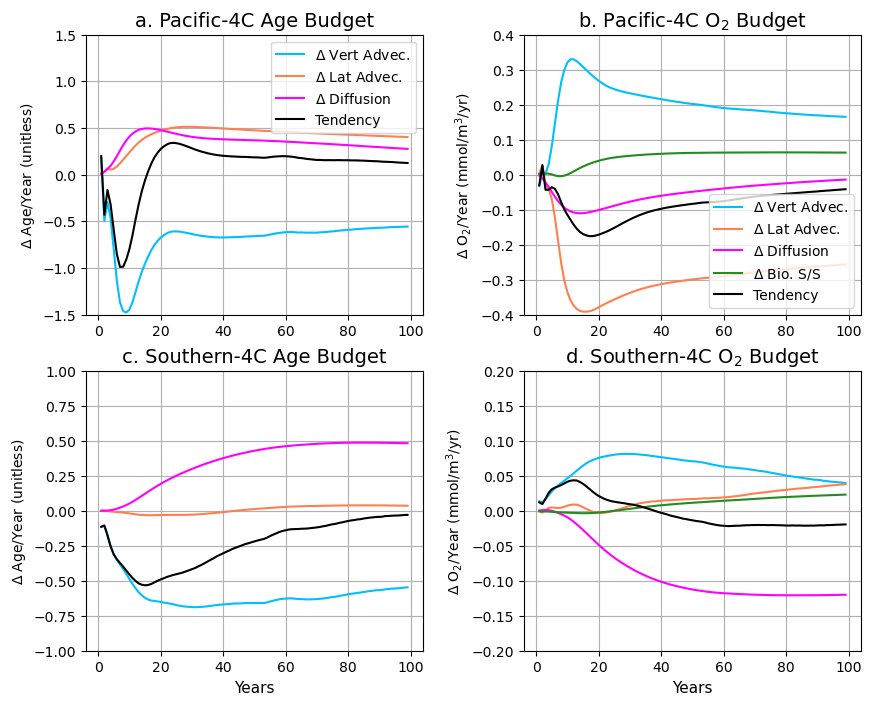

In [23]:
#oldmask = xr.load_dataarray('../Yohei_2018/old_tropical_mask.nc')

## building the timeseries figure that I'm excited about. 
# Version 1, with just the budget terms. 

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [10,8]) 
oldmask = xr.load_dataarray('../Yohei_2018/OMZmask.nc')
plt.subplots_adjust(wspace=0.3)
tfon = 14
yrx = np.arange(1,100)

myZ = np.arange(8,13)

## Pac O2
toPl2 = o2regts(PacO2.terms.advr_nd_O2 - CtlO2.terms.advr_nd_O2, oldmask, myZ)
axs[0,1].plot(yrx, 360*1000*toPl2, label = '$\Delta$ Vert Advec.', color = 'deepskyblue')
toPl = (o2regts(PacO2.terms.advct_O2 - CtlO2.terms.advct_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*(toPl - toPl2), label = '$\Delta$ Lat Advec.', color='coral')

toPl3 = (o2regts(PacO2.terms.diffu_O2 - CtlO2.terms.diffu_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl3, label = '$\Delta$ Diffusion', color = 'magenta')

toPl5 = (o2regts(PacO2.terms.Bio_O2 - CtlO2.terms.Bio_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl5, label = '$\Delta$ Bio. S/S', color = 'forestgreen')
toPl4 = (o2regts(PacO2.terms.Tend_O2 - CtlO2.terms.Tend_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl4, label = 'Tendency', color = 'black')
axs[0,1].legend( loc='lower right', fontsize = 10)
axs[0,1].grid()
axs[0,1].set_ylim([-0.4,0.4])
axs[0,1].set_title('b. Pacific-4C O$_2$ Budget', fontsize = tfon)
axs[0,1].set_ylabel('$\\Delta$ O$_2$/Year (mmol/m$^3$/yr)', fontsize = 10)


## SO O2
toPl2 = o2regts(SOO2.terms.advr_nd_O2 - CtlO2.terms.advr_nd_O2, oldmask, myZ)
axs[1,1].plot(yrx, 360*1000*toPl2, label = 'Vert adv.', color = 'deepskyblue')
toPl = (o2regts(SOO2.terms.advct_O2 - CtlO2.terms.advct_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*(toPl - toPl2), label = 'Lateral adv.', color='coral')

toPl3 = (o2regts(SOO2.terms.diffu_O2 - CtlO2.terms.diffu_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl3, label = 'Diffusion', color = 'magenta')

toPl5 = (o2regts(SOO2.terms.Bio_O2 - CtlO2.terms.Bio_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl5, label = 'Biological S/S', color = 'forestgreen')
toPl4 = (o2regts(SOO2.terms.Tend_O2 - CtlO2.terms.Tend_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl4, label = 'Tendency', color = 'black')
axs[1,1].set_ylabel('$\\Delta$ O$_2$/Year (mmol/m$^3$/yr)', fontsize = 10)

axs[1,1].grid()
axs[1,1].set_ylim([-0.2,0.2])
axs[1,1].set_title('d. Southern-4C O$_2$ Budget', fontsize = tfon)
axs[1,1].set_xlabel('Years', fontsize = 11)
#plt.legend(ax = axs[0,1], loc='lower right')

## Pac-4c age
toPl2 = o2regts(PacAge.terms.advr_nd_Age - CtlAge.terms.advr_nd_Age, oldmask, myZ)
axs[0,0].plot(yrx, 360*toPl2, label = '$\Delta$ Vert Advec.', color = 'deepskyblue')
toPl = (o2regts(PacAge.terms.advct_Age - CtlAge.terms.advct_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*(toPl - toPl2), label =  '$\Delta$ Lat Advec.', color='coral')

toPl3 = (o2regts(PacAge.terms.diffu_Age - CtlAge.terms.diffu_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*toPl3, label = '$\Delta$ Diffusion', color = 'magenta')
toPl4 = (o2regts(PacAge.terms.Tend_Age - CtlAge.terms.Tend_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*toPl4, label =  'Tendency', color = 'black')
axs[0,0].grid()
axs[0,0].set_ylim([-1.5,1.5])
axs[0,0].legend( loc='upper right', fontsize = 10)
axs[0,0].set_title('a. Pacific-4C Age Budget', fontsize = tfon)
axs[0,0].set_ylabel('$\\Delta$ Age/Year (unitless)', fontsize = 10)


## SO Age
toPl2 = o2regts(SOAge.terms.advr_nd_Age - CtlAge.terms.advr_nd_Age, oldmask, myZ)
axs[1,0].plot(yrx, 360*toPl2, label = '$\Delta$ Vert Advec.', color = 'deepskyblue')
toPl = (o2regts(SOAge.terms.advct_Age - CtlAge.terms.advct_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*(toPl - toPl2), label =  '$\Delta$ Lat Advec.', color='coral')
toPl3 = (o2regts(SOAge.terms.diffu_Age - CtlAge.terms.diffu_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*toPl3, label = 'Diffusion', color = 'magenta')
toPl4 = (o2regts(SOAge.terms.Tend_Age - CtlAge.terms.Tend_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*toPl4, label =  'Tendency', color = 'black')
axs[1,0].set_ylim([-1,1])
axs[1,0].grid()
axs[1,0].set_title('c. Southern-4C Age Budget', fontsize = tfon)
axs[1,0].set_ylabel('$\\Delta$ Age/Year (unitless)', fontsize = 10)
axs[1,0].set_xlabel('Years', fontsize = 11)

#plt.legend(loc = 'upper right')
#plt.grid()
#plt.title('ETP Age change under SO-4C')

#plt.grid()
#plt.title('ETP O2 change under Pacific-4C')

#letters = ['a','b','c','d']
#for i in range(2):
#    for j in range(2):
#        axs[i,j].text(0.05, 0.96, letters[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')

plt.savefig('../eps_figures/budget_timeseries4-30.eps', bbox_inches="tight")



In [22]:
SOAge.terms.Tend_Age.shape

(99, 23, 64, 128)

## Supplementary Mean Budget figures

In [6]:
folGl = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4Cstep_try1/'
folNA = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4CNA_try1/'
folOtho = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/OthO4C_try1/'

NA3d = xmitgcm.open_mdsdataset(folNA, grid_dir = fol3, prefix = [ 'DynDiag3d','AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#vol = Pac3d.drF*Pac3d.hFacC*Pac3d.rA
Gl3d = xmitgcm.open_mdsdataset(folGl, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#Ctl3d = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#Low3d = xmitgcm.open_mdsdataset(folOtho, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)

NASn = xmitgcm.open_mdsdataset(folNA, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)
GlSn = xmitgcm.open_mdsdataset(folGl, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)

Otho3d = xmitgcm.open_mdsdataset(folOtho, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
OthoSn = xmitgcm.open_mdsdataset(folOtho, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)





In [7]:
NAAge = AgeBud(NA3d, NASn)
NAAge.calc_all()
GlAge = O2age_budget.AgeBudgetND(Gl3d, GlSn)
GlAge.calc_all()
OthoAge = AgeBud(Otho3d, OthoSn)
OthoAge.calc_all()

GlO2 = O2age_budget.OxygenBudget(Gl3d, GlSn)
GlO2.calc_all()
NAO2 = O2age_budget.OxygenBudget(NA3d, NASn)
NAO2.calc_all()
OthoO2 = O2age_budget.OxygenBudget(Otho3d, OthoSn)
OthoO2.calc_all()


/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a

In [60]:
xran = range(42,105)
yran = range(12,53)
zran = range(8,13)


tmpPacO2 = PacO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
PacO2map = tmpPacO2.sum('Z')/deps.sum('Z')
tmpPacAge = PacAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
PacAgemap = tmpPacAge.sum('Z')/deps.sum('Z')


tmpGlO2 = GlO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
GlO2map = tmpGlO2.sum('Z')/deps.sum('Z')
tmpGlAge = GlAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
GlAgemap = tmpGlAge.sum('Z')/deps.sum('Z')

tmpNAO2 = NAO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
NAO2map = tmpNAO2.sum('Z')/deps.sum('Z')
tmpNAAge = NAAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
NAAgemap = tmpNAAge.sum('Z')/deps.sum('Z')

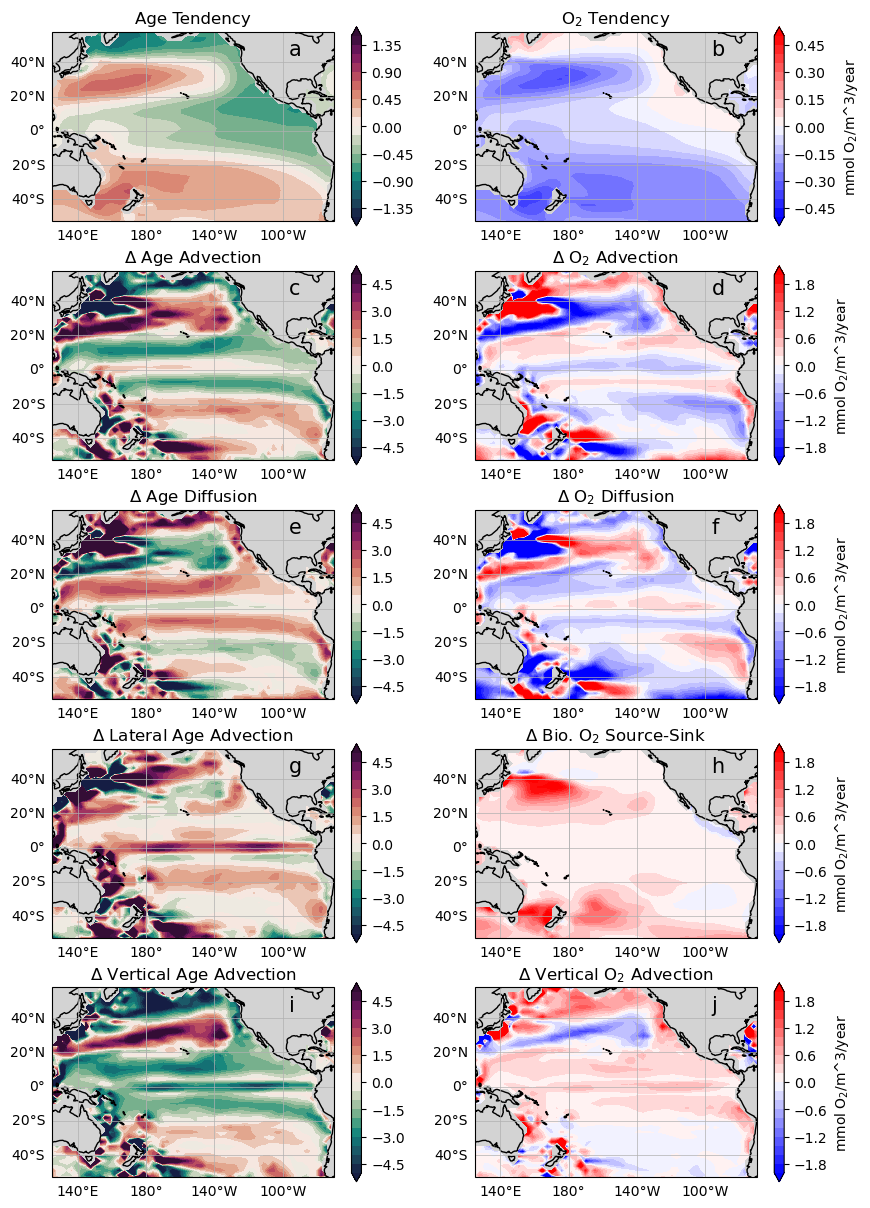

In [62]:
# OK trying to rewrite the Pacific version to make life way easier. 

## here's the plotting one ... 

import cmocean
agemap = cmocean.cm.curl
omap = 'bwr'

Diag3d = Pac3d

vm= 5
vmo = 2
vmt = 1.5
vmot = 0.5

ForcO = GlO2map
ForcA = GlAgemap
CtlO = CtlO2map
CtlA = CtlAgemap


# this is truly not working. OK not a priority!! 
proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(ncols=2 , nrows=5, figsize=(10,15), subplot_kw={'projection': proj})
plt.rcParams['text.usetex'] = False

E = axs[0,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.Tend_Age -CtlA.Tend_Age)  , vmin = -vmt, vmax = vmt, levels = np.linspace(-vmt, vmt,21), cmap = agemap, extend = 'both', transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(E, ax= axs[0,0])
#axs[0,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[0,0].grid()

F = axs[0,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*360*(ForcO.Tend_O2- CtlO.Tend_O2), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Fcb=plt.colorbar(F, ax= axs[0,1])
Fcb.set_label('mmol O$_2$/m^3/year')
#axs[0,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[0,1].grid()


axs[0,0].set_title('Age Tendency')
axs[0,1].set_title('O$_2$ Tendency')



C = axs[1,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*( ForcA.advct_Age- CtlA.advct_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ccb = plt.colorbar(C, ax= axs[1,0])

#axs[1,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[1,0].grid()

D = axs[1,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*360*(ForcO.advct_O2- CtlO.advct_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Dcb = plt.colorbar(D, ax= axs[1,1])
Dcb.set_label('mmol O$_2$/m^3/year')

#axs[1,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[1,1].grid()


axs[1,0].set_title('$\Delta$ Age Advection')
axs[1,1].set_title('$\Delta$ O$_2$ Advection')


C = axs[2,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.diffu_Age - CtlA.diffu_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[2,0])
#axs[2,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[2,0].grid()

D = axs[2,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.diffu_O2 - CtlO.diffu_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ecb = plt.colorbar(D, ax= axs[2,1])
Ecb.set_label('mmol O$_2$/m^3/year')
#axs[2,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[2,1].grid()


axs[2,0].set_title('$\Delta$ Age Diffusion')
axs[2,1].set_title('$\Delta$ O$_2$ Diffusion')

A = axs[3,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.advct_Age - ForcA.advr_nd_Age - CtlA.advct_Age + CtlA.advr_nd_Age), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[3,0])
#axs[3,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,0].grid()

B = axs[3,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.Bio_O2 - CtlO.Bio_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Bcb = plt.colorbar(B, ax= axs[3,1])
Bcb.set_label('mmol O$_2$/m^3/year')
#axs[3,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,1].grid()

axs[3,0].set_title('$\Delta$ Lateral Age Advection') #$\Delta [w *d(Age)/dz]$')
axs[3,1].set_title('$\Delta$ Bio. O$_2$ Source-Sink') #$\Delta [w *d(Age)/dz]$')



M = axs[4,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.advr_nd_Age - CtlA.advr_nd_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(M, ax= axs[4,0])
#axs[3,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,0].grid()

N = axs[4,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.advr_nd_O2- CtlO.advr_nd_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ncb = plt.colorbar(N, ax= axs[4,1])
Ncb.set_label('mmol O$_2$/m^3/year')
#axs[3,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,1].grid()
axs[4,0].set_extent([140, 20, 30, 60], crs = proj)
axs[4,0].set_title('$\Delta$ Vertical Age Advection') #$\Delta [w *d(Age)/dz]$')
axs[4,1].set_title('$\Delta$ Vertical O$_2$ Advection') #$\Delta [w *d(Age)/dz]$')

#plt.savefig('Age_Budget_maps.eps')
letters = ['a','b','c','d','e','f','g','h','i','j']
for i in range(5):
    for j in range(2):
        axs[i,j].text(0.84, 0.96, letters[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')
        axs[i,j].grid()
        axs[i,j].coastlines()
        axs[i,j].set_extent([110, -55, -53, 58], crs = proj)
        gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
        gl.top_labels=False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 40))
        axs[i,j].set_facecolor('lightgray')
#consider cutting this off at 1500 m instead? 
#plt.savefig('eps_figures/budget_SOmaps8-19.eps')
#plt.savefig('eps_figures/budget_SOmaps10-8_v2.eps')
#plt.savefig('../eps_figures/budget_Glmaps11-14.eps')



In [2]:
45678

45678

In [ ]:
## old version of budget map code, for the record

# ## Calculating the maps needed for Southern Ocean oxygen
# here we're using the entire time period, because it better shows tendency...
xran = range(42,105)
yran = range(12,53)
zran = range(8,13)

#PlSO = ageSO.isel( XC = xran, YC = yran, Z= zran).mean('Z')
deps = Pac3d.drF.isel(Z=zran)*Pac3d.hFacC.isel(XC = xran, YC = yran, Z= zran)
#tmpPaw = PacAge.terms.advr_nd_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmpSOw = SOO2.terms.advr_nd_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmp0w = CtlO2.terms.advr_nd_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps

PoSOw = tmpSOw.sum('Z')/deps.sum('Z')
#PPacw = tmpPaw.sum('Z')/deps.sum('Z')
Po0w = tmp0w.sum('Z')/deps.sum('Z')

# advection
tmpSOv = SOO2.terms.advct_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps  
tmp0v = CtlO2.terms.advct_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PoSOv = tmpSOv.sum('Z')/deps.sum('Z')
Po0v = tmp0v.sum('Z')/deps.sum('Z')

# diffusion
tmpSOd = SOO2.terms.diffu_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmp0d =  CtlO2.terms.diffu_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PoSOd = tmpSOd.sum('Z')/deps.sum('Z')
Po0d = tmp0d.sum('Z')/deps.sum('Z')

# tendency
tmpSOt = SOO2.terms.Tend_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmp0t =  CtlO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PoSOt = tmpSOt.sum('Z')/deps.sum('Z')
Po0t = tmp0t.sum('Z')/deps.sum('Z')

# biology!
tmpSOb = SOO2.terms.Bio_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmp0b =  CtlO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PoSOb = tmpSOb.sum('Z')/deps.sum('Z')
Po0b = tmp0b.sum('Z')/deps.sum('Z')

#PoAtend = PacO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran).mean('XC').mean('time')
#Po0tend = CtlO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran).mean('XC').mean('time')
#
#PoAbio = PacO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran).mean('XC').mean('time')
#Po0bio = CtlO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran).mean('XC').mean('time')

## Age calculated below.

deps = Pac3d.drF.isel(Z=zran)*Pac3d.hFacC.isel(XC = xran, YC = yran, Z= zran)
#tmpPaw = PacAge.terms.advr_nd_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmpSOw = SOAge.terms.advr_nd_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmp0w = CtlAge.terms.advr_nd_Age.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
PlSOw = tmpSOw.sum('Z')/deps.sum('Z')
Pl0w = tmp0w.sum('Z')/deps.sum('Z')

#tmpPav = PacAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmpSOv = SOAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps  
tmp0v = CtlAge.terms.advct_Age.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PlSOv = tmpSOv.sum('Z')/deps.sum('Z')
#PlPacv = tmpPav.sum('Z')/deps.sum('Z')
Pl0v = tmp0v.sum('Z')/deps.sum('Z')

#tmpPat = PacAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps +PacAge.terms.diffu_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmpSOt = SOAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps  +SOAge.terms.diffu_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmp0t = CtlAge.terms.advct_Age.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps +CtlAge.terms.diffu_Age.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PlSOt = tmpSOt.sum('Z')/deps.sum('Z')
#PlPact = tmpPat.sum('Z')/deps.sum('Z')
Pl0t = tmp0t.sum('Z')/deps.sum('Z')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


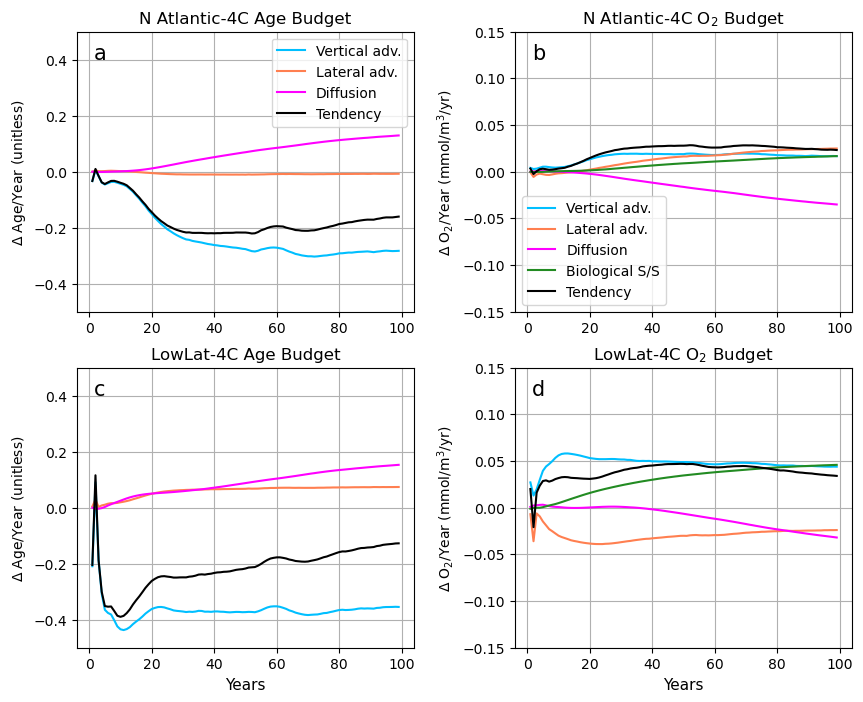

In [14]:
#oldmask = xr.load_dataarray('../Yohei_2018/old_tropical_mask.nc')

## timeseries figure, now for LowLat and North Atlantic for supplement

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [10,8]) 
oldmask = xr.load_dataarray('../Yohei_2018/OMZmask.nc')
plt.subplots_adjust(wspace=0.3)

yrx = np.arange(1,100)

myZ = np.arange(8,13)
toPl2 = o2regts(NAO2.terms.advr_nd_O2 - CtlO2.terms.advr_nd_O2, oldmask, myZ)
axs[0,1].plot(yrx, 360*1000*toPl2, label = 'Vertical adv.', color = 'deepskyblue')
toPl = (o2regts(NAO2.terms.advct_O2 - CtlO2.terms.advct_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*(toPl - toPl2), label = 'Lateral adv.', color='coral')

toPl3 = (o2regts(NAO2.terms.diffu_O2 - CtlO2.terms.diffu_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl3, label = 'Diffusion', color = 'magenta')

toPl5 = (o2regts(NAO2.terms.Bio_O2 - CtlO2.terms.Bio_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl5, label = 'Biological S/S', color = 'forestgreen')
toPl4 = (o2regts(NAO2.terms.Tend_O2 - CtlO2.terms.Tend_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl4, label = 'Tendency', color = 'black')
axs[0,1].legend( loc='lower left', fontsize = 10)
axs[0,1].grid()
axs[0,1].set_ylim([-0.15,0.15])
axs[0,1].set_title('N Atlantic-4C O$_2$ Budget')
axs[0,1].set_ylabel('$\\Delta$ O$_2$/Year (mmol/m$^3$/yr)', fontsize = 10)


## SO age 
toPl2 = o2regts(OthoO2.terms.advr_nd_O2 - CtlO2.terms.advr_nd_O2, oldmask, myZ)
axs[1,1].plot(yrx, 360*1000*toPl2, label = 'Vertical adv.', color = 'deepskyblue')
toPl = (o2regts(OthoO2.terms.advct_O2 - CtlO2.terms.advct_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*(toPl - toPl2), label = 'Lateral adv.', color='coral')

toPl3 = (o2regts(OthoO2.terms.diffu_O2 - CtlO2.terms.diffu_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl3, label = 'Diffusion', color = 'magenta')

toPl5 = (o2regts(OthoO2.terms.Bio_O2 - CtlO2.terms.Bio_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl5, label = 'Biological S/S', color = 'forestgreen')
toPl4 = (o2regts(OthoO2.terms.Tend_O2 - CtlO2.terms.Tend_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl4, label = 'Tendency', color = 'black')
axs[1,1].set_ylabel('$\\Delta$ O$_2$/Year (mmol/m$^3$/yr)', fontsize = 10)

axs[1,1].grid()
axs[1,1].set_ylim([-0.15,0.15])
axs[1,1].set_title('LowLat-4C O$_2$ Budget')
axs[1,1].set_xlabel('Years', fontsize = 11)
#plt.legend(ax = axs[0,1], loc='lower right')

## Pac-4c age
toPl2 = o2regts(NAAge.terms.advr_nd_Age - CtlAge.terms.advr_nd_Age, oldmask, myZ)
axs[0,0].plot(yrx, 360*toPl2, label = 'Vertical adv.', color = 'deepskyblue')
toPl = (o2regts(NAAge.terms.advct_Age - CtlAge.terms.advct_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*(toPl - toPl2), label =  'Lateral adv.', color='coral')

toPl3 = (o2regts(NAAge.terms.diffu_Age - CtlAge.terms.diffu_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*toPl3, label = 'Diffusion', color = 'magenta')
toPl4 = (o2regts(NAAge.terms.Tend_Age - CtlAge.terms.Tend_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*toPl4, label =  'Tendency', color = 'black')
axs[0,0].grid()
axs[0,0].set_ylim([-0.5,0.5])
axs[0,0].legend( loc='upper right', fontsize = 10)
axs[0,0].set_title('N Atlantic-4C Age Budget')
axs[0,0].set_ylabel('$\\Delta$ Age/Year (unitless)', fontsize = 10)

toPl2 = o2regts(OthoAge.terms.advr_nd_Age - CtlAge.terms.advr_nd_Age, oldmask, myZ)
axs[1,0].plot(yrx, 360*toPl2, label = 'vertical adv', color = 'deepskyblue')
toPl = (o2regts(OthoAge.terms.advct_Age - CtlAge.terms.advct_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*(toPl - toPl2), label =  'lateral adv', color='coral')
toPl3 = (o2regts(OthoAge.terms.diffu_Age - CtlAge.terms.diffu_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*toPl3, label = 'diffusion', color = 'magenta')
toPl4 = (o2regts(OthoAge.terms.Tend_Age - CtlAge.terms.Tend_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*toPl4, label =  'Tendency', color = 'black')
axs[1,0].set_ylim([-0.5,0.5])
axs[1,0].grid()
axs[1,0].set_title('LowLat-4C Age Budget')
axs[1,0].set_ylabel('$\\Delta$ Age/Year (unitless)', fontsize = 10)
axs[1,0].set_xlabel('Years', fontsize = 11)

#plt.legend(loc = 'upper right')
#plt.grid()
#plt.title('ETP Age change under SO-4C')

#plt.grid()
#plt.title('ETP O2 change under Pacific-4C')

#plt.savefig('../eps_figures/supp_budget_ts11-30.eps')

letters = ['a','b','c','d']
for i in range(2):
    for j in range(2):
        axs[i,j].text(0.05, 0.96, letters[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')




In [15]:
ls ../eps_figures/.

7-9-2025/                                 Fig1_MITgcm_maps_812.eps
Agemap8-14.eps                            Fig1_MITgcm_maps_812.pdf
Agemap8-14.pdf                            Fig1_MITgcm_maps_8-27.eps
Agemaps7-21.eps                           Fig1_MITgcm_maps.eps
Agemaps7-21.pdf                           Fig1_MITgcm_maps.pdf
age_o2_aou_sections11-14.eps              Fig1_with_obs10-31.eps
age_o2_aou_sections8-14.eps               Fig1_with_obs11-21.eps
age_o2_aou_sections8-14.pdf               Fig_with_obs10-31.eps
AgeO2maps11-14.eps                        mean_budget_section_8-27.eps
AgeO2maps8-19.eps                         myfigure.pdf
AgeO2maps8-19.pdf                         O2maps7-21.eps
budget_Glmaps11-14.eps                    O2maps7-21.pdf
budget_Pacmaps11-14.eps                   O2maps8-14.eps
budget_sections7-25.eps                   O2maps8-14.pdf
budget_sections7-25.pdf                   Obs_O2_10-9.eps
budget_sections8-12.eps                   Obs_supp_O2_11-21.eps
bu